<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks-EN/2.1-feature-extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Extraction (Feature Extraction) - RAVDESS

The *Ryerson Audio-Visual Database of Emotional Speech and Song* (RAVDESS) is a multimodal dataset used for emotion recognition in audio signals and speech processing.

## General characteristics
- 7,356 files in total — **1,440 audio-only**.  
- 24 actors (12 men, 12 women).  
- Two English utterances with similar semantic content.  
- Recordings with North American accent.  

## Emotions
- 01: *neutral*  
- 02: *calm*  
- 03: *happy*  
- 04: *sad*  
- 05: *angry*  
- 06: *fearful*  
- 07: *disgust*  
- 08: *surprised*  

## Modalities
- Audio (`.wav`, 48 kHz, 16-bit).  
- Audio + video.  
- Video without audio.  

## Intensity
- 01: normal  
- 02: strong (*strong*)  
- (The *neutral* emotion appears only with normal intensity).  

## Directory structure
```text
ravdess/
├── Actor_01/
├── Actor_02/
...
├── Actor_24/
```

## Naming convention
Format:
`modality-vocal_channel-emotion-intensity-statement-repetition-actor.wav`

Example:
`03-01-06-01-02-01-12.wav`

## Field meaning
| Pos | Field         | Description |
|-----|---------------|-------------|
| 1   | Modality      | 01=audio+video, 02=video, 03=audio |
| 2   | Vocal channel | 01=speech, 02=song |
| 3   | Emotion       | See emotion list |
| 4   | Intensity     | 01=normal, 02=strong |
| 5   | Statement     | 01=kids..., 02=dogs... |
| 6   | Repetition    | 01=first, 02=second |
| 7   | Actor         | 01–24 (odd=man, even=woman) |

## Interpreted example
File: `03-01-06-01-02-01-12.wav`

- **03**: Audio  
- **01**: Speech (*speech*)  
- **06**: Fear (*fearful*)  
- **01**: Normal intensity  
- **02**: Sentence 2  
- **01**: Repetition 1  
- **12**: Actor 12 (woman)

---
**Note:** For practical purposes, it is recommended to run this *notebook* preferably in Google Colab. Thanks to its compatibility with the `kagglehub` library, the dataset can be imported directly from Kaggle. This streamlines the workflow by avoiding manual downloads and preventing unnecessary storage use, both locally and in the cloud.

In [2]:
import kagglehub
import os
import IPython.display as ipd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import logging
import sys
from google.colab import drive

In [4]:
#drive.mount('/content/drive')
# Download the latest version from Kaggle
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
path_crema = kagglehub.dataset_download("ejlok1/cremad")
# Paths
BASE_DIR = "/kaggle/input/ravdess-emotional-speech-audio"
BASE_DIR_CREMA = "/kaggle/input/cremad"

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Using Colab cache for faster access to the 'cremad' dataset.


In [5]:
# List the dataset directory contents to verify its content
print(f"Contenido de la carpeta del dataset: {path}")
print(os.listdir(BASE_DIR))

Contenido de la carpeta del dataset: /kaggle/input/ravdess-emotional-speech-audio
['Actor_02', 'Actor_17', 'Actor_05', 'Actor_16', 'Actor_21', 'Actor_01', 'Actor_11', 'Actor_20', 'Actor_08', 'Actor_15', 'Actor_06', 'Actor_12', 'Actor_23', 'Actor_24', 'Actor_22', 'Actor_04', 'Actor_19', 'Actor_10', 'Actor_09', 'audio_speech_actors_01-24', 'Actor_14', 'Actor_03', 'Actor_13', 'Actor_18', 'Actor_07']


In [6]:
print(f"Contenido de la carpeta del dataset: {path_crema}")
print(os.listdir(BASE_DIR_CREMA))

Contenido de la carpeta del dataset: /kaggle/input/cremad
['AudioWAV']


In [7]:
# Playback of a file with clip -05- (Angry)
base_dir_actor_01 = "/kaggle/input/ravdess-emotional-speech-audio/Actor_01"
angry_clip = os.path.join(base_dir_actor_01, "03-01-05-02-02-01-01.wav")
ipd.Audio(angry_clip)

### CREMA-D vs. RAVDESS

It is worth noting that the [CREMA-D](https://www.kaggle.com/datasets/ejlok1/cremad) dataset, unlike **RAVDESS**, presents greater variability in its audio files; this comparison is analyzed in more detail in the notebook [**4.2-feature-extraction.ipynb**](https://github.com/AcSsalazar/the-color-of-emotions/blob/main/Notebooks-EN/4.2-feature-extraction-rav_and_crema.ipynb).

To give an idea of the kind of data we will find in **CREMA-D**, in the next clip you can notice the presence of a natural acoustic filter. These additional characteristics are fundamental for our model to achieve better **generalization**, and they also avoid the need to generate synthetic files through the manual application of filters or noise (*data augmentation*).

> For the **RAVDESS** case, at this stage of the project I decided not to generate synthetic audio. The purpose is to train a base model with the original dataset (which has a smaller data volume) to compare its performance against the model that will use the expanded image set generated from both datasets. See: [**4.2-feature-extraction.ipynb**](https://github.com/AcSsalazar/the-color-of-emotions/blob/main/Notebooks-EN/4.2-feature-extraction-rav_and_crema.ipynb).

In [8]:
sample_crema = "/kaggle/input/cremad/AudioWAV/1001_DFA_ANG_XX.wav"
ipd.Audio(sample_crema)

### Duration processing and silence removal

To achieve proper processing of the audio clips, it is necessary to set a uniform duration for all files. For this, we will use Librosa's `trim` function, which removes silences according to a given threshold. In addition, we will apply padding, which lets us fill with zeros those signals that do not reach the required minimum duration.

As we can see below, if an overly aggressive criterion is applied—for example, trimming sounds that are 20 dB below the clip’s maximum threshold—there is a risk of losing valuable information. For this reason, we determined that the `top_db` parameter provides a balanced trim when set between 40 and 45. This range is not so strict that it removes low-volume segments that still contain relevant information, nor so permissive that it preserves silences that are unimportant.

Text(0.5, 1.0, 'Trim 40 dB')

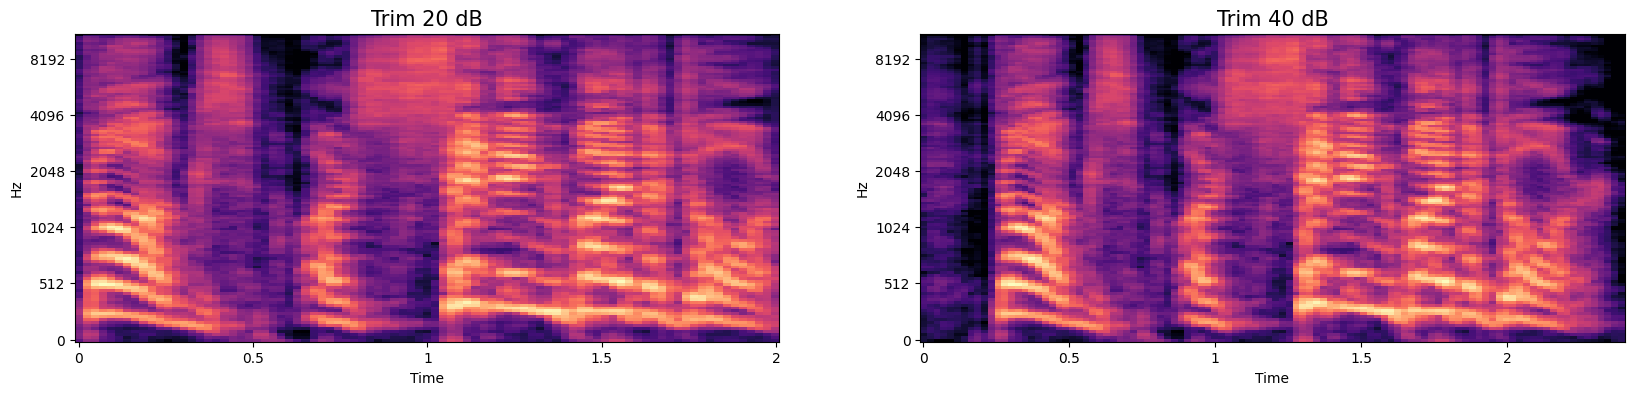

In [9]:
SAMPLE_RATE = 22050
signal, sr = librosa.load(angry_clip, sr=SAMPLE_RATE)
# Trim con 20 dB
signal_out_20, _ = librosa.effects.trim(signal, top_db=20)
mel_trimm_20 = librosa.feature.melspectrogram(y=signal_out_20, sr=sr, n_mels=128)
mel_trimm_20_db = librosa.power_to_db(mel_trimm_20, ref=np.max)
# Trim con 40 dB
signal_out_40, _ = librosa.effects.trim(signal, top_db=40)
mel_trimm_40 = librosa.feature.melspectrogram(y=signal_out_40, sr=sr, n_mels=128)
mel_trimm_40_db = librosa.power_to_db(mel_trimm_40, ref=np.max)

plt.figure(figsize=(20, 4))
plt.subplot(1, 2, 1) #1 Fila, 2 columnas, 1er plot
librosa.display.specshow(mel_trimm_20_db,
                         sr=sr,
                         x_axis='time',
                         y_axis='mel')
plt.title('Trim 20 dB', fontsize=15)

plt.subplot(1, 2, 2) #1 Fila, 2 columnas, 2do plot
librosa.display.specshow(mel_trimm_40_db,
                         sr=sr,
                         x_axis='time',
                         y_axis='mel'
                         )
plt.title('Trim 40 dB', fontsize=15)




### Impact of trimming

As can be observed, applying trim with a 20 dB parameter produces a cut at the start of the phrase that removes useful information from our final dataset. If this phenomenon repeats across the 1,440 files in the dataset, the cumulative loss of information would be significant for model training.

Nevertheless, as we will see below, to our ears these two audio clips may sound exactly the same, which shows that what is imperceptible to humans can be critical for a machine-learning algorithm.

In [10]:
ipd.Audio(signal_out_20, rate=sr)

In [11]:
ipd.Audio(signal_out_40, rate=sr)

Next, we will extract 8 fundamental features from each audio clip. It is worth noting that, in many scripts working with the RAVDESS dataset, Delta and Delta-Delta coefficients are not usually included. However, in the interest of experimentation and learning, we decided to include these metrics because they provide information about temporal dynamics that is considered highly relevant.

Later, we will evaluate whether model performance and scores change significantly when training without these characteristics.

In [13]:
# Feature extraction (from audio to dataframe - csv):

# Configuration variables
#--------------------------------------------------------------------------
DATASET_PATH = '/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24'
SAMPLE_RATE = 22050
MIN_DURATION = 0.5
MAX_DURATION = 4
GENERATE_CSV = False
GENERATE_IMAGES = False # Set to False to only get DF (CSV part)
PAD_MODE = "constant" # Para padding de audios cortos
OUT_DIR_IMAGES = '/content/ravdess_images/'
OUT_DIR_IMAGES_02 = '/content/ravdess_images_02/'
OUT_DIR_CSV = '/content/ravdess_features/features.csv'
BATCH_SIZE_CSV = 60 # Depende cuanto RAM usemos
IMG_RES_01 = (128,128) # Resolucion recomendad
IMG_RES_02 = (224,224) # Para ResNet
IMG_RES_03 = (512,256) # Multiple resolutions for later tests
#--------------------------------------------------------------------------

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    stream=sys.stdout,
                    force=True
                    )

# Counters for clip processing

processed_count=0
discarded_count=0
error_count=0

# Extraction functions:

# We know that in e.g. RAVDESS: 03-01-XX-01-01-01-01.wav -> XX corresponds to the emotion

# Function to group by emotion

def get_emotion_from_filename(filename):
    try:
        parts = filename.split('-')
        emotion_code = int(parts[2]) # Position where XX is
        emotion_map = {1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised'}
        return emotion_map.get(emotion_code, 'unknown')
    except:
        return 'unknown'

# process_audio function
def process_audio(file_path, sr=SAMPLE_RATE, min_dur=MIN_DURATION, max_dur=MAX_DURATION):
    global discarded_count, error_count
    try:
        # As we saw, it is more convenient not to be too aggressive and to use 40 in top_db
        y, sr = librosa.load(file_path, sr=sr)
        y_trimmed, _ = librosa.effects.trim(y, top_db=40)
        y_trimmed = librosa.util.normalize(y_trimmed)
        duration = len(y_trimmed) / sr
        y = y_trimmed


        if duration < min_dur or duration > max_dur:
            logging.info(f"Discarded {os.path.basename(file_path)}: duration {duration:.2f}s")
            discarded_count += 1
            return None

        # Not necessary if you normalize and configure the output image resolution (to obtain images).
        # Essential in matrix operations
        '''target_len = int(max_dur * sr)
        if len(y_trimmed) < target_len:
            y_trimmed = np.pad(y_trimmed, (0, target_len - len(y_trimmed)), mode=PAD_MODE)'''

        return y_trimmed, sr
    except Exception as e:
        logging.error(f"Error in {file_path}: {e}")
        discarded_count += 1
        return None


def extract_features(y, sr):
    try:
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13) # With 13 mfccs  (filters)
        delta = librosa.feature.delta(mfccs)
        delta2 = librosa.feature.delta(mfccs, order=2)
        rmse = librosa.feature.rms(y=y)
        spec = librosa.stft(y)
        spec_db = librosa.amplitude_to_db(np.abs(spec))
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048)
        mel_spec_db = librosa.power_to_db(mel_spec)

        features = {
            'mfcc_mean': np.mean(mfccs, axis=1), 'mfcc_std': np.std(mfccs, axis=1),
            'delta_mean': np.mean(delta, axis=1), 'delta_std': np.std(delta, axis=1),
            'delta2_mean': np.mean(delta2, axis=1), 'delta2_std': np.std(delta2, axis=1),
            'rmse_mean': np.mean(rmse), 'rmse_std': np.std(rmse),
            'spec_mean': np.mean(spec_db), 'spec_std': np.std(spec_db),
            'mel_mean': np.mean(mel_spec_db), 'mel_std': np.std(mel_spec_db)
        }
        flat_features = np.concatenate([
            features['mfcc_mean'], features['mfcc_std'], features['delta_mean'], features['delta_std'],
            features['delta2_mean'], features['delta2_std'],
            [features['rmse_mean'], features['rmse_std'], features['spec_mean'], features['spec_std'],
             features['mel_mean'], features['mel_std']]
        ])
        return flat_features, mfccs, delta, delta2, spec_db, mel_spec_db
    except Exception as e:
        logging.error(f"Error features: {e}")
        return None, None, None, None, None, None


# Initial debug
print(f"Path del dataset: {DATASET_PATH}")
print(f"Duration range: {MIN_DURATION}s - {MAX_DURATION}s")
print(f"Generate images: {GENERATE_IMAGES}")


# Main with batches
data_dir = DATASET_PATH
files_list = [os.path.join(root, file) for root, dirs, files in os.walk(data_dir) for file in files if file.endswith('.wav')]
logging.info(f"Total files: {len(files_list)}")

# Flag to avoid generating the csv again:
if GENERATE_CSV:


    features_list = []
    labels = []
    for i in range(0, len(files_list), BATCH_SIZE_CSV):
        batch_files = files_list[i:i+BATCH_SIZE_CSV]
        logging.info(f"Processing batch {i//BATCH_SIZE_CSV + 1} / {(len(files_list)//BATCH_SIZE_CSV) + 1}")
        for file_path in batch_files:
            processed = process_audio(file_path)
            if processed:
                y, sr = processed
                feats, mfccs, delta, delta2, spec_db, mel_spec_db = extract_features(y, sr)
                if feats is not None:
                    features_list.append(feats)
                    emotion = get_emotion_from_filename(os.path.basename(file_path))
                    labels.append(emotion)
                    processed_count += 1


        # Free memory
        import gc
        gc.collect()
        logging.info(f"Batch {i//BATCH_SIZE_CSV + 1} completed. Processed count: {processed_count}, Discarded: {discarded_count}, Errors: {error_count}")

    # Final statistics
    logging.info(f"Finish. Total processed: {processed_count}, Discarded: {discarded_count}, Errors: {error_count}")
    print(f"Sumary: Processed {processed_count}, Discarded {discarded_count}, Errors {error_count}")


    # Create and save DF
    columns = ([f'mfcc_mean_{i}' for i in range(13)] + [f'mfcc_std_{i}' for i in range(13)] +
              [f'delta_mean_{i}' for i in range(13)] + [f'delta_std_{i}' for i in range(13)] +
              [f'delta2_mean_{i}' for i in range(13)] + [f'delta2_std_{i}' for i in range(13)] +
              ['rmse_mean', 'rmse_std', 'spec_mean', 'spec_std', 'mel_mean', 'mel_std'])
    df = pd.DataFrame(features_list, columns=columns)
    df['emotion'] = labels
    scaler = StandardScaler()
    df[columns] = scaler.fit_transform(df[columns])
    df.to_csv(OUT_DIR_CSV, index=False)
    logging.info(f"DF saved at {OUT_DIR_CSV} with {len(df)} rows")

else:
  print("CSV file generation is disabled")

Path del dataset: /kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24
Duration range: 0.5s - 4s
Generate images: False
2026-05-17 01:43:44,130 - INFO - Total files: 1440
CSV file generation is disabled


### Preview of processed clips

It is essential to perform a preview or representative sample to validate data consistency and thus avoid processing the entire set—along with the considerable waiting time it entails—only to discover poorly processed images.

This debugging phase allows us to refine transformation parameters (such as trim or spectrogram scale) and guarantee a high-quality dataset for model training.

In [14]:
def plot_preview(emotion, file_path=None):
    """
    Generate a plot to visualize the audio features associated with a given emotion.
    If file_path is not provided, search for a file within the dataset.

    Args:
        emotion: string. Nombre de la emotion a plotear.
        file_path: string. Optional path to the specific audio file.
    """
    try:
        # Files related to the emotion
        if not file_path:
            matched_files = [
                file for file in files_list
                if get_emotion_from_filename(os.path.basename(file)) == emotion
            ]
            if not matched_files:
                print(f"No file found with emotion: {emotion}")
                return
            file_path = matched_files[0]  # Choose the first file

        print(f"Using file: {file_path} to visualize the emotion: {emotion}")

        # Process the audio
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        y_trimmed, _ = librosa.effects.trim(y, top_db=40)
        y_trimmed = librosa.util.normalize(y_trimmed)

        # Extract features from trimmed audio (y_trimmed)
        _, mfccs, delta, delta2, spec_db, mel_spec_db = extract_features(y_trimmed, sr)

        # Extract features from original audio (y)
        _, mfccs_ori, delta_ori, delta2_ori, spec_db_ori, mel_spec_db_ori = extract_features(y, sr)

        # Initial configuration to force visualizations depending on the environment
        # This ensures plots show in some environments like notebooks or scripts
        plt.close('all')  # Close any previous figure to avoid conflicts
        fig, axs = plt.subplots(5, 2, figsize=(12, 20))

        # Plot MFCC
        mfcc_img = librosa.display.specshow(mfccs, x_axis='time', sr=sr, cmap='coolwarm', ax=axs[0, 0])
        axs[0, 0].set_title("MFCC (Trimmed)", fontsize=10)

        mfcc_img_ori = librosa.display.specshow(mfccs_ori, x_axis='time', sr=sr, cmap='coolwarm', ax=axs[0, 1])
        axs[0, 1].set_title("MFCC (Original)", fontsize=10)

        # Plot MFCC delta
        delta_img = librosa.display.specshow(delta, x_axis='time', sr=sr, cmap='coolwarm', ax=axs[1, 0])
        axs[1, 0].set_title("Delta de MFCC (Trimmed)", fontsize=10)
        delta_img_ori = librosa.display.specshow(delta_ori, x_axis='time', sr=sr, cmap='coolwarm', ax=axs[1, 1])
        axs[1, 1].set_title("Delta de MFCC (Original)", fontsize=10)

        # Plot MFCC delta-delta
        delta2_img = librosa.display.specshow(delta2, x_axis='time', sr=sr, cmap='coolwarm', ax=axs[2, 0])
        axs[2, 0].set_title("Delta-Delta de MFCC (Trimmed)", fontsize=10)
        delta2_img_ori = librosa.display.specshow(delta2_ori, x_axis='time', sr=sr, cmap='coolwarm', ax=axs[2, 1])
        axs[2, 1].set_title("Delta-Delta de MFCC (Original)", fontsize=10)

        # Plot spectrogram (STFT)
        spec_img = librosa.display.specshow(spec_db, x_axis='time', y_axis='hz', sr=sr, cmap='cividis', ax=axs[3, 0])
        axs[3, 0].set_title("Espectrograma (STFT) (Trimmed)", fontsize=10)
        spec_img_ori = librosa.display.specshow(spec_db_ori, x_axis='time', y_axis='hz', sr=sr, cmap='cividis', ax=axs[3, 1])
        axs[3, 1].set_title("Espectrograma (STFT) (Original)", fontsize=10)

        # Plot Mel spectrogram
        mel_img = librosa.display.specshow(mel_spec_db, x_axis='time', y_axis='mel', sr=sr, cmap='magma', ax=axs[4, 0])
        axs[4, 0].set_title("Espectrograma de Mel (Trimmed)", fontsize=10)
        mel_img_ori = librosa.display.specshow(mel_spec_db_ori, x_axis='time', y_axis='mel', sr=sr, cmap='magma', ax=axs[4, 1])
        axs[4, 1].set_title("Espectrograma de Mel (Original)", fontsize=10)



        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error processing the emotion or file: {e}")

In [15]:
%matplotlib inline

Using file: /kaggle/input/ravdess-emotional-speech-audio/Actor_01/03-01-05-02-02-01-01.wav to visualize the emotion: angry


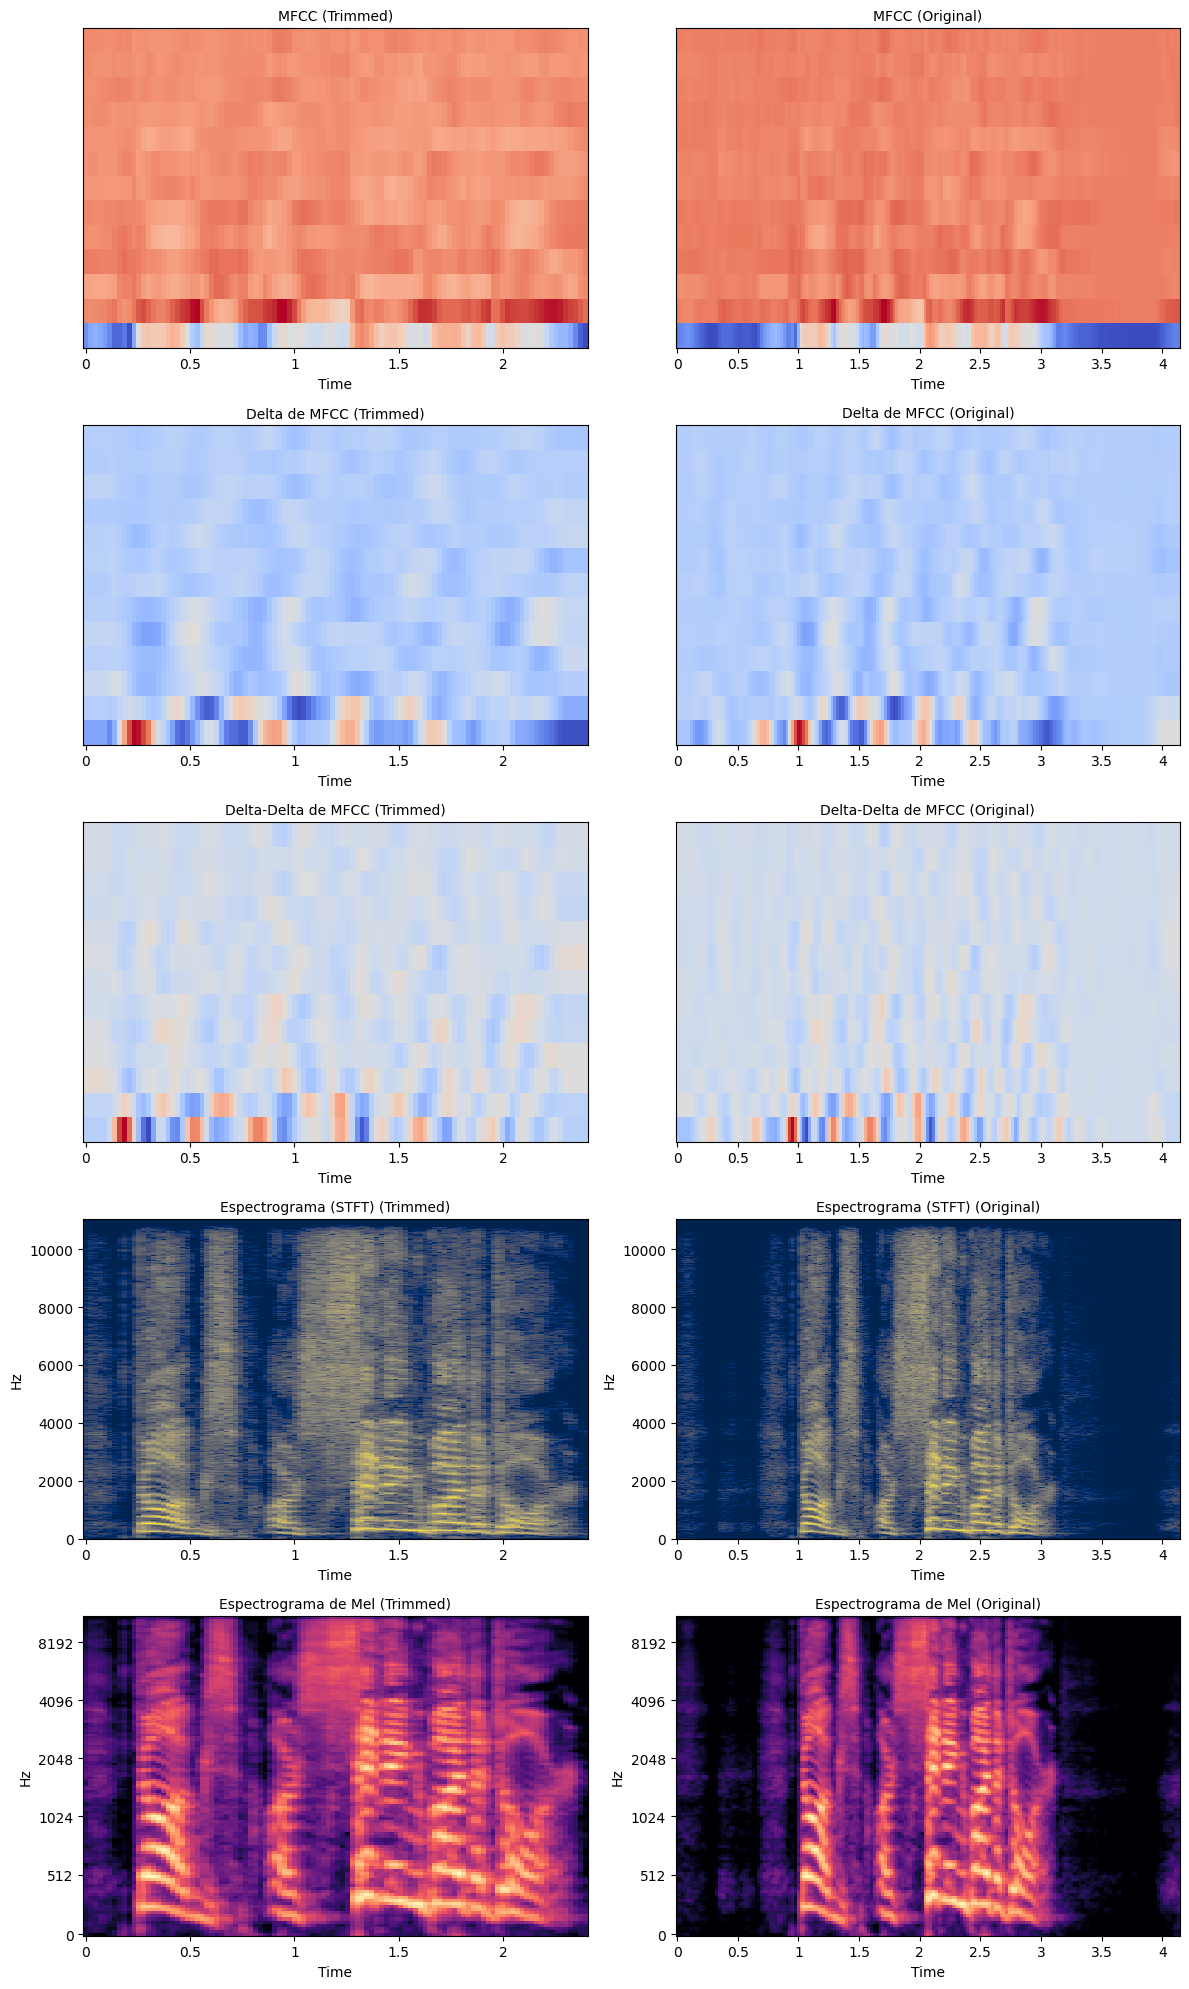

In [16]:
plot_preview('angry', angry_clip)

### Preview of the final file (.csv)

In [ ]:
df = pd.read_csv(OUT_DIR_CSV)
df.head(10)

In [ ]:
print("Conteo por clases:")
print("\n")
print("* El dataframe contiene:", len(df.columns), "Columnas por",  len(df), "filas")
print("* Total discarded due to duration is:", discarded_count)
df['emotion'].value_counts()

## Square image generation
To have direct control over the output resolution of our images (e.g., 224x224 px)—since ResNet (and almost all computer vision architectures in Deep Learning) operate internally on matrices of numbers where each number represents a pixel—it is necessary to carry out the operations corresponding to lines of code `21` to `27` in the next cell.

This is because in Matplotlib the size of an image is not defined directly in pixels, but in inches (figsize) multiplied by the pixel density or DPI (dots per inch). Therefore, we must perform the mathematical conversion to ensure the output file has the exact pixel dimensions required by the model.

In [17]:
# Generate images separately to optimize RAM usage:
import matplotlib
import psutil
import gc
GENERATE_IMAGES = True
BATCH_SIZE_IMAGES = 60


matplotlib.use('Agg')  # No-GUI backend: leave uncommented for efficiency


if GENERATE_IMAGES:
  # save_images function (same, but with Drive)
  def save_images(mfccs, delta, delta2, spec_db, mel_spec_db, emotion, file_path, output_dir=OUT_DIR_IMAGES_02, res=IMG_RES_02):
      try:
          base_name = os.path.basename(file_path).replace('.wav', '')
          # Calculate exact dimensions
          pixel_width, pixel_height = res[0], res[1]
          my_dpi = 100
          for feature_name, data in [('mfcc', mfccs), ('delta', delta), ('delta2', delta2), ('spec', spec_db), ('mel_spec', mel_spec_db)]:
              # 1. Create figure with exact size in inches

              fig = plt.figure(figsize=(pixel_width/my_dpi, pixel_height/my_dpi), dpi=my_dpi)

              # 2. Force the axis to occupy the whole figure (no borders)
              ax = fig.add_axes([0, 0, 1, 1])
              ax.axis('off')

              if feature_name in ['mfcc', 'delta', 'delta2']:
                  librosa.display.specshow(data, sr=SAMPLE_RATE, ax=ax, cmap='coolwarm')
              else:
                  librosa.display.specshow(data, sr=SAMPLE_RATE, ax=ax, cmap='inferno')

              os.makedirs(os.path.join(output_dir, feature_name, emotion), exist_ok=True)

              # 3. Save WITHOUT bbox_inches='tight'
              plt.savefig(
                  os.path.join(output_dir, feature_name, emotion, f'{base_name}.png'),
                  dpi=my_dpi
              )
              plt.close(fig)

      except Exception as e:
          logging.error(f"Image error {file_path}: {e}")


  for i in range (0, len(files_list), BATCH_SIZE_IMAGES):
      batch_files = files_list[i:i+BATCH_SIZE_IMAGES]
      logging.info(f"Generating images batch {i//BATCH_SIZE_IMAGES + 1} / {((len(files_list) - 1) // BATCH_SIZE_IMAGES) + 1}")
      for file_path in batch_files:
          processed = process_audio(file_path)
          if processed:
              y, sr = processed
              feats, mfccs, delta, delta2, spec_db, mel_spec_db = extract_features(y, sr)
              if feats is not None:
                  emotion = get_emotion_from_filename(os.path.basename(file_path))
                  save_images(mfccs, delta, delta2, spec_db, mel_spec_db, emotion, file_path, res=IMG_RES_02) # Change res to save correctly
                  # Libera todo
                  del y, feats, mfccs, delta, delta2, spec_db, mel_spec_db
      gc.collect()
      logging.info(f"Image batch completed. RAM: {psutil.virtual_memory().used / (1024**3):.2f} GB")

  logging.info("Images generated correctly")

else:
  print("Image generation is disabled")

2026-05-17 01:44:26,070 - INFO - Generating images batch 1 / 24
2026-05-17 01:44:47,794 - INFO - Image batch completed. RAM: 1.69 GB
2026-05-17 01:44:47,795 - INFO - Generating images batch 2 / 24
2026-05-17 01:45:10,884 - INFO - Image batch completed. RAM: 1.58 GB
2026-05-17 01:45:10,885 - INFO - Generating images batch 3 / 24
2026-05-17 01:45:34,046 - INFO - Discarded 03-01-02-02-01-02-05.wav: duration 4.25s
2026-05-17 01:45:34,244 - INFO - Image batch completed. RAM: 1.29 GB
2026-05-17 01:45:34,245 - INFO - Generating images batch 4 / 24
2026-05-17 01:45:54,949 - INFO - Image batch completed. RAM: 1.28 GB
2026-05-17 01:45:54,950 - INFO - Generating images batch 5 / 24
2026-05-17 01:46:17,901 - INFO - Image batch completed. RAM: 1.27 GB
2026-05-17 01:46:17,902 - INFO - Generating images batch 6 / 24
2026-05-17 01:46:40,492 - INFO - Image batch completed. RAM: 1.29 GB
2026-05-17 01:46:40,493 - INFO - Generating images batch 7 / 24
2026-05-17 01:47:01,823 - INFO - Image batch completed

In [33]:
# process_audio function
def process_audio_with_padding(file_path, sr=SAMPLE_RATE, min_dur=MIN_DURATION, max_dur=MAX_DURATION):
    global discarded_count, error_count
    try:
        # As we saw, it is more convenient not to be too aggressive and to use 40 in top_db
        y, sr = librosa.load(file_path, sr=sr)
        y_trimmed, _ = librosa.effects.trim(y, top_db=40)
        y_trimmed = librosa.util.normalize(y_trimmed)
        duration = len(y_trimmed) / sr


        #
        target_len = int(max_dur * sr)
        if len(y_trimmed) < target_len:
          zps  = (target_len - len(y_trimmed))
          zps_l = int(zps // 2)
          zps_r = zps - zps_l

          y_trimmed = np.pad(y_trimmed, (zps_l,zps_r), mode=PAD_MODE)

        return y_trimmed[:target_len], sr
    except Exception as e:
        logging.error(f"Error in {file_path}: {e}")
        discarded_count += 1
        return None


def plot_emotion_mean(emotion, feature_name, cmap_type='twilight'):
    """
    Compute and plot the average of a specific feature for a given emotion.

    Args:
        emotion: string, la emotion que queremos analizar (debe coincidir con el resultado de get_emotion_from_filename).
        feature_name: string, the name of the feature to plot (e.g., 'mfcc', 'delta', etc.).
    """

    # Filter files by emotion
    emotion_files = [file for file in files_list if get_emotion_from_filename(os.path.basename(file)) == emotion]
    if not emotion_files:
        print(f"No audio files found for the emotion: {emotion}")
        return

    print(f"Processing {len(emotion_files)} audio files for the emotion: {emotion}")
    print(f"Feature: {feature_name} with {cmap_type}")

    # Process audios and collect features
    feature_values = []
    for file_path in emotion_files:
        processed = process_audio_with_padding(file_path)
        if processed:
            y, sr = processed
            # Extract features
            _, mfccs, delta, delta2, spec_db, mel_spec_db = extract_features(y, sr)

            # Map the feature name to the corresponding value
            if feature_name == 'mfcc':
                feature_values.append(mfccs)
            elif feature_name == 'delta':
                feature_values.append(delta)
            elif feature_name == 'delta2':
                feature_values.append(delta2)
            elif feature_name == 'spec_db':
                feature_values.append(spec_db)
            elif feature_name == 'mel_spec_db':
                feature_values.append(mel_spec_db)
            else:
                print(f"Unknown feature: {feature_name}")
                return

    if not feature_values:
        print(f"Could not extract values for the feature {feature_name} emotion {emotion}")
        return

    # Compute the time average (horizontal axis) across all audios

    avg_feature = np.mean(np.array(feature_values), axis=0)

    # Plot the average of the feature
    plt.figure(figsize=(10, 6))
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)
    plt.axis('off')



    # Based on SAMPLE_RATE, set min and max for the frequency range where the human voice lives

    f_min = 20
    f_max = SAMPLE_RATE // 2

    if feature_name in ['mfcc', 'delta', 'delta2']:  # Estructura tiempo vs indices, no usamos ni Mel ni Log
        librosa.display.specshow(avg_feature, x_axis='time',
                                 y_axis=None,
                                 sr=SAMPLE_RATE,
                                 cmap= cmap_type)
        plt.axis('off')
        #plt.title(f"Average of {feature_name} for emotion: {emotion}")
        #plt.colorbar()
    elif feature_name == 'spec_db':  # Espectrogramas (frecuencia x tiempo)
        librosa.display.specshow(avg_feature,  x_axis='time',
                                 y_axis='linear',
                                 sr=SAMPLE_RATE,
                                 fmin=f_min,
                                 fmax=f_max,
                                 cmap= cmap_type)
        #plt.title(f"Average of {feature_name} for emotion: {emotion}")

    elif feature_name == 'mel_spec_db':
      librosa.display.specshow(avg_feature,  x_axis='time',
                                 y_axis='mel',
                                 fmin = f_min,
                                 fmax = f_max,
                                 sr=SAMPLE_RATE,
                                 cmap = cmap_type)
    else:
        print(f"Feature {feature_name} not supported for visualization.")
        return
    plt.savefig(f"avg_{emotion}_{feature_name}.png", bbox_inches='tight', pad_inches=0)
    plt.tight_layout()
    plt.show()


### Emotion colormap configuration (RAVDESS dataset)

To add more visual expressiveness to the feature averages, I defined a color palette that represents the color of each emotion:

| ID | Emotion | Colormap (`cmap`) | Visual description |
|:---:|:---|:---|:---|
| 01 | **Neutral** | `viridis` | Uniform, balanced perception. |
| 02 | **Calm** | `Blues` | Cool, relaxed, low-intensity tones. |
| 03 | **Happy** | `YlGn` | Brightness and vitality (Yellow to Green). |
| 04 | **Sad** | `bone` | Bluish grayscale, somber and muted. |
| 05 | **Angry** | `inferno` | Maximum heat, energy, and aggressive contrast. |
| 06 | **Fearful** | `PuBu` | Purples and blues, tension and depth. |
| 07 | **Disgust** | `pink` | Subtle, desaturated organic tones. |
| 08 | **Surprised** | `RdGy` | Sudden contrast between red and gray (alert). |

> **Note:** You can consult the [Matplotlib documentation](https://matplotlib.org/stable/users/explain/colors/colormaps.html) to select the color palette you consider appropriate, according to how each emotion might look.

In [21]:
%matplotlib inline

# **Neutral**

Processing 96 audio files for the emotion: neutral
Feature: spec_db with viridis


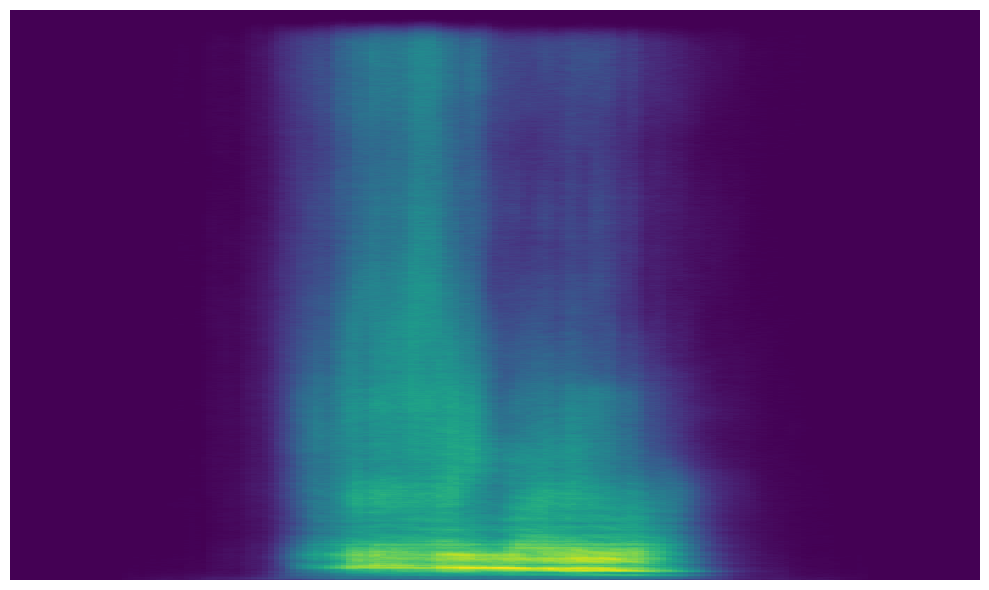

In [34]:
# plot_emotion_mean('emotion', 'feature', 'cmap_type')
plot_emotion_mean('neutral', 'spec_db', 'viridis')

# **Calm**

Processing 192 audio files for the emotion: calm
Feature: spec_db with Blues


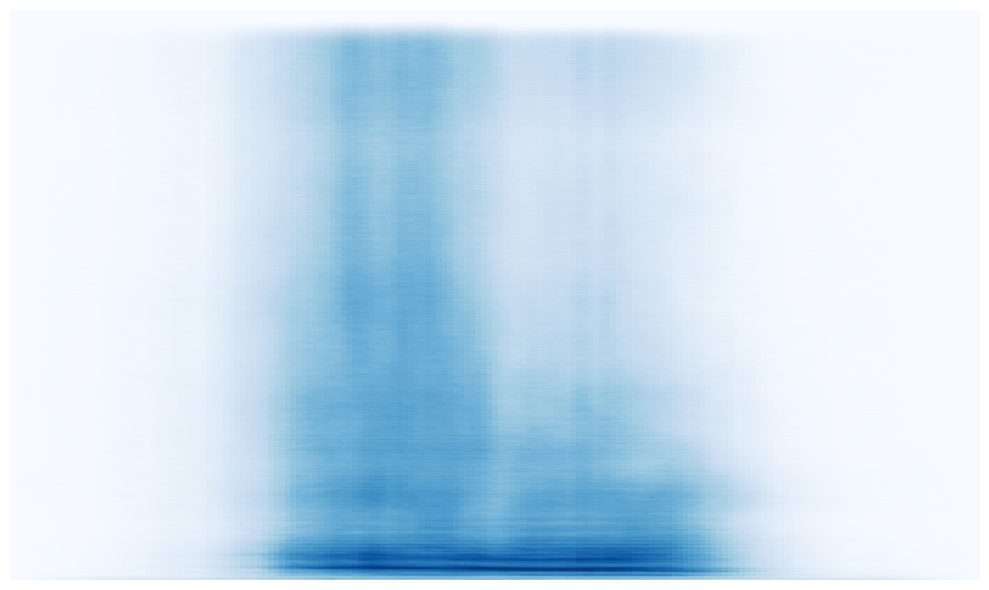

In [35]:
plot_emotion_mean('calm', 'spec_db', 'Blues')

# **Happiness**

Processing 192 audio files for the emotion: happy
Feature: spec_db with YlGn


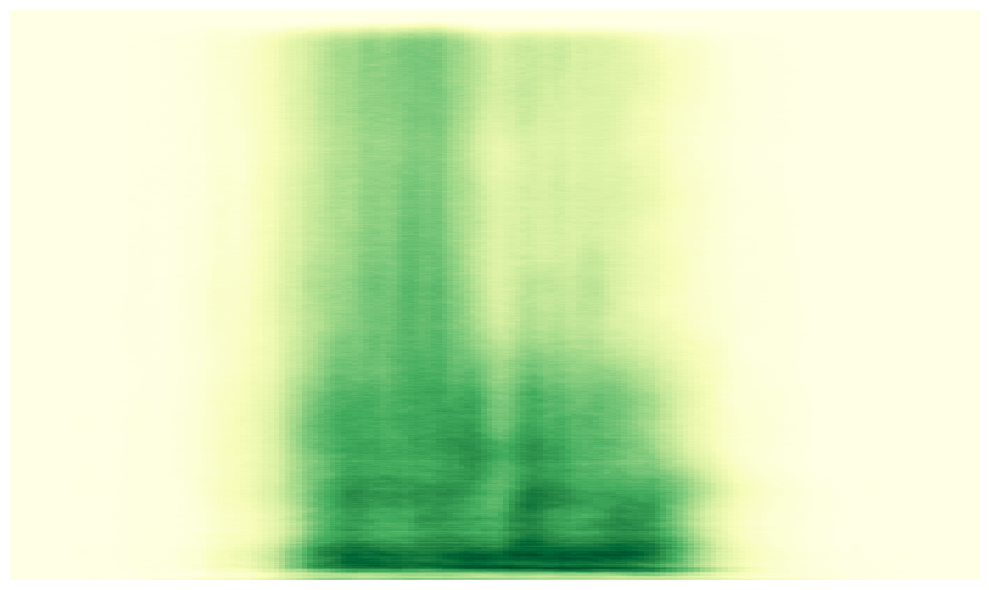

In [36]:
plot_emotion_mean('happy', 'spec_db', 'YlGn')

# **Sadness**

Processing 192 audio files for the emotion: sad
Feature: spec_db with bone


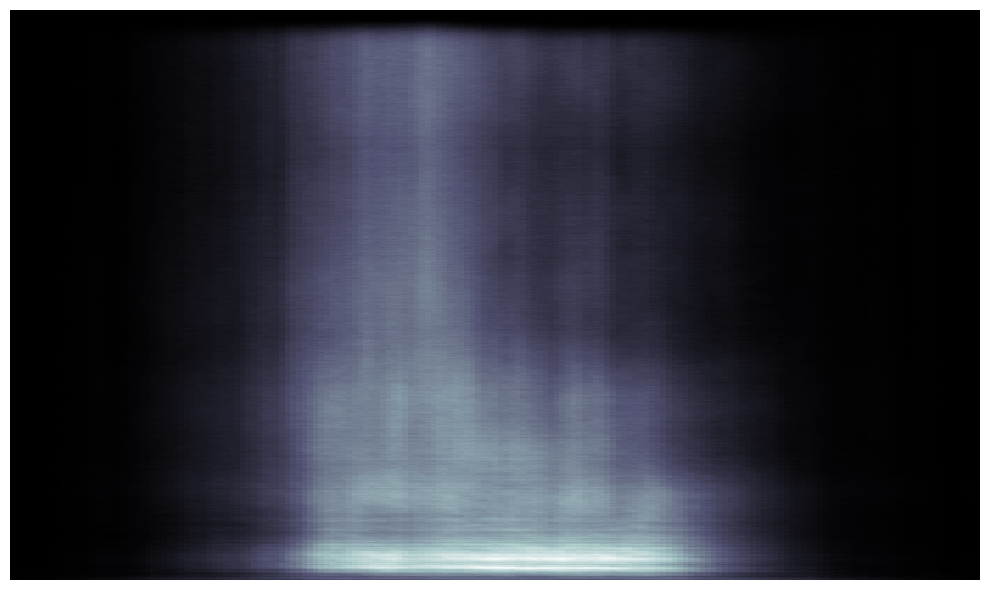

In [37]:
plot_emotion_mean('sad', 'spec_db', 'bone')

# **Anger**

Processing 192 audio files for the emotion: angry
Feature: spec_db with inferno


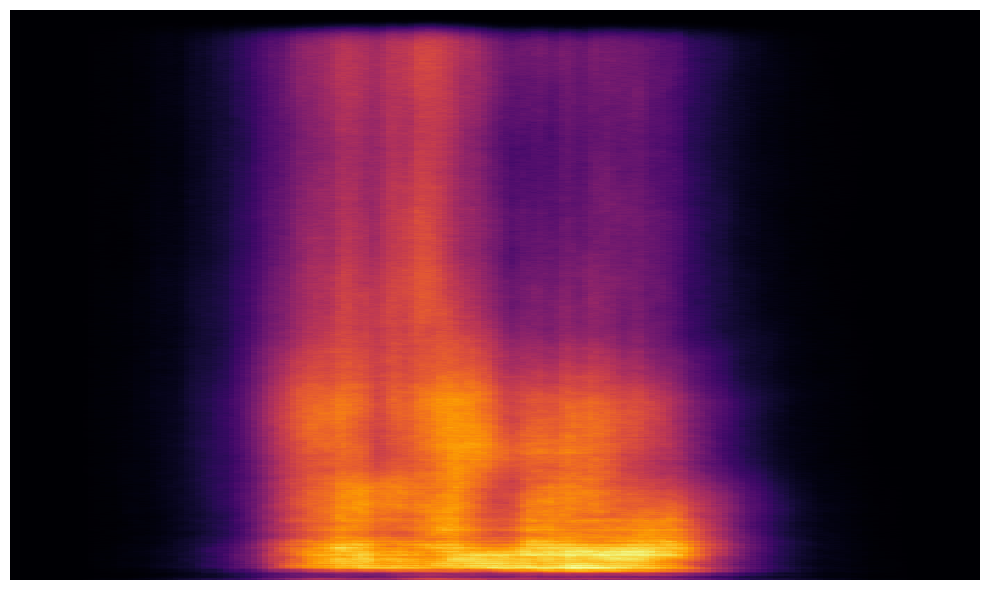

In [38]:
plot_emotion_mean('angry', 'spec_db', 'inferno')

# **Fear**

Processing 192 audio files for the emotion: fearful
Feature: spec_db with PuBu


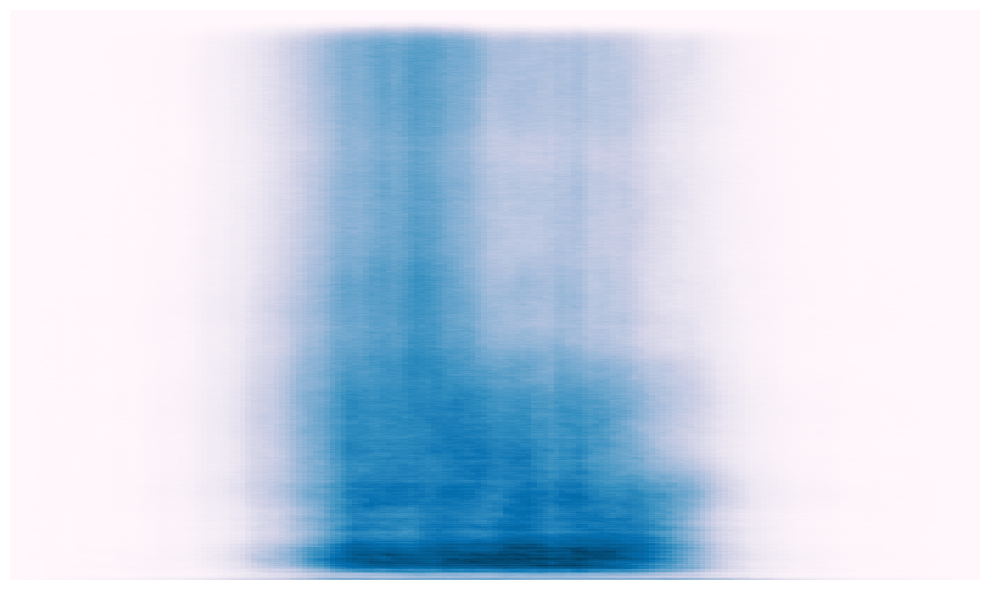

In [39]:
plot_emotion_mean('fearful', 'spec_db', 'PuBu')

# **Disgust**

Processing 192 audio files for the emotion: disgust
Feature: spec_db with pink


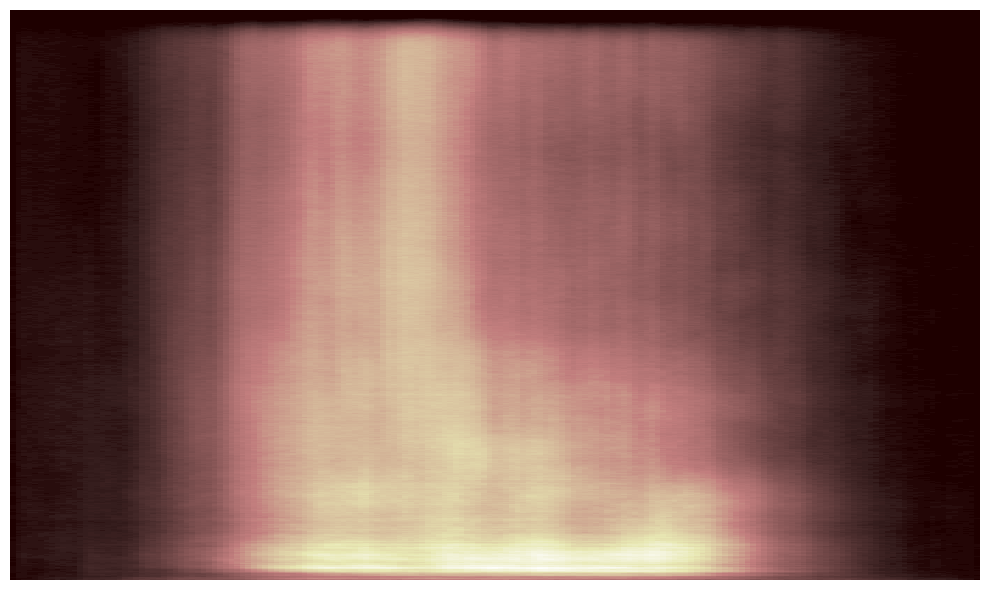

In [40]:
plot_emotion_mean('disgust', 'spec_db', 'pink')

# **Surprise**

Processing 192 audio files for the emotion: surprised
Feature: spec_db with RdGy


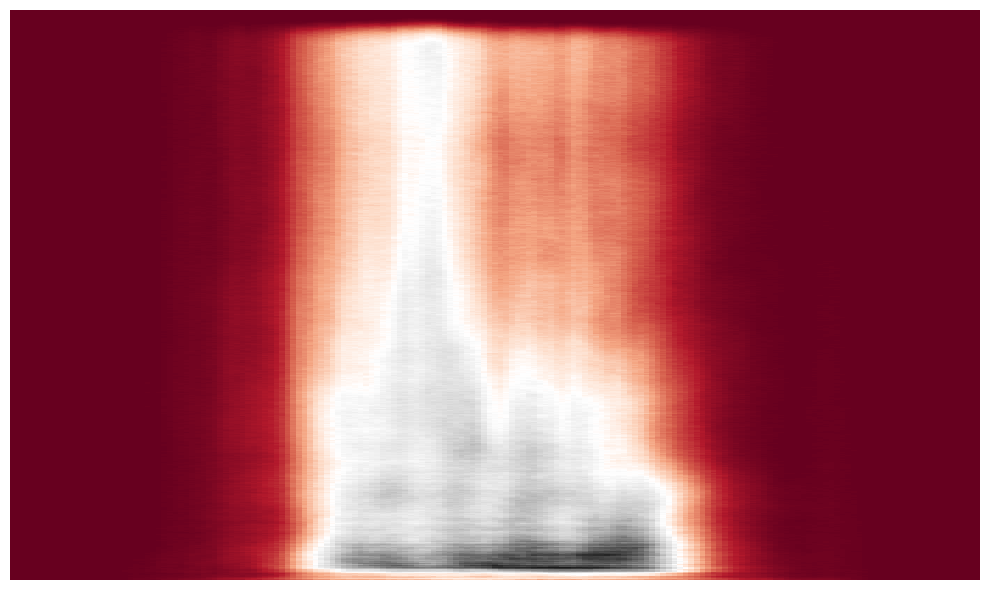

In [41]:
plot_emotion_mean('surprised', 'spec_db', 'RdGy')

**Conclusion and next steps**

With this we conclude this part of the project. In the following notebooks, we will train, test, and evaluate our Machine Learning, Deep Learning, and Fine-Tuning models based on the features extracted here.

I hope that, by this point, you are at least a little convinced that digital audio processing carries that magic each of us finds in the world around us and that we perceive through our senses; in this case, hearing.

**Download the generated images by clicking the following link:** **[Download](https://drive.google.com/file/d/1r3i1lLnpfIqtrfv-6d9p84RDky4E5wnF/view?usp=sharing)**

*Thanks for visiting this repository.*